# 03 — State B FEA-Constrained Revision

Build the FEA prompt from State A, generate the revised CAD, and compare the before/after geometry.


In [5]:
from base64 import b64encode
from pathlib import Path
import json
import logging
import os
import sys

import yaml
from IPython.display import HTML, Image, Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "code_base").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
MODULE_ROOT = PROJECT_ROOT / "code_base" / "fea_cad_one_sample"
if str(MODULE_ROOT) not in sys.path:
    sys.path.insert(0, str(MODULE_ROOT))

API_ENV_PATH = MODULE_ROOT / "src" / "api.env"


def _load_api_env(path: Path) -> dict[str, str]:
    """Load a local api.env file into the current process environment."""

    env_values: dict[str, str] = {}
    if not path.exists():
        return env_values
    for raw_line in path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip("'").strip('"')
        if key and value:
            env_values[key] = value
            os.environ.setdefault(key, value)
    return env_values


api_env_values = _load_api_env(API_ENV_PATH)

from src import interfaces as api

logging.basicConfig(level=logging.INFO, format="%(name)s | %(levelname)s | %(message)s")

def _img(path: Path, width: int = 260) -> str:
    data = b64encode(Path(path).read_bytes()).decode("ascii")
    return f'<img src="data:image/png;base64,{data}" width="{width}" />'

def display_image_row(title: str, items: list[tuple[str, Path]], width: int = 260) -> None:
    cells = []
    for label, path in items:
        cells.append(f'<td style="padding:8px;text-align:center;vertical-align:top"><div><b>{label}</b></div>{_img(path, width)}</td>')
    html = '<h3>{}</h3><table><tr>{}</tr></table>'.format(title, ''.join(cells))
    display(HTML(html))

FIXED_SAMPLE_PATH = MODULE_ROOT / "experiment_config" / "fixed_sample.yaml"
OUTPUT_ROOT = MODULE_ROOT / "outputs"
sample_config = yaml.safe_load(FIXED_SAMPLE_PATH.read_text(encoding="utf-8"))
sample_id = str(sample_config["sample_id"])
connection_string = os.environ["CAD_DB_CONNECTION_STRING"]
state_a_dir = OUTPUT_ROOT / f"sample_{sample_id}" / "01_dataset_original"
state_b_dir = OUTPUT_ROOT / f"sample_{sample_id}" / "02_fea_constrained_revision"
comparison_dir = OUTPUT_ROOT / f"sample_{sample_id}" / "03_comparison"
state_b_dir.mkdir(parents=True, exist_ok=True)
comparison_dir.mkdir(parents=True, exist_ok=True)
pipeline_config = api.PipelineConfig(
    config_name="config_gpt_5_4_mini.yaml",
    config_path=MODULE_ROOT / "src" / "copied_from_cadcodeverify" / "configs" / "config_gpt_5_4_mini.yaml",
    output_root=OUTPUT_ROOT,
    force=True,
)

print("[STAGE] Setup")
print(f"  → sample id   : {sample_id}")
print(f"  → state A dir : {state_a_dir}")
print(f"  → state B dir : {state_b_dir}")
print(f"  → compare dir : {comparison_dir}")
print(f"  → api.env     : {API_ENV_PATH}")
print(f"  → api.env keys: {sorted(api_env_values)}")


[STAGE] Setup
  → sample id   : 00689964
  → state A dir : /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original
  → state B dir : /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/02_fea_constrained_revision
  → compare dir : /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/03_comparison
  → api.env     : /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/src/api.env
  → api.env keys: ['CAD_DB_CONNECTION_STRING', 'LANGFUSE_BASE_URL', 'LANGFUSE_ENABLED', 'LANGFUSE_PUBLIC_KEY', 'LANGFUSE_SECRET_KEY', 'OPENAI_API_KEY', 'OPENROUTER_API_KEY']


src.db.load_sample | INFO | load_sample | start | sample_id=00689964 | random=False | expert_random=False
src.db.load_sample | INFO | load_sample_by_id | start | sample_id=00689964
src.db.load_sample | INFO | load_sample_by_id | done | sample_id=00689964 | prompt_variant=expert
src.db.load_sample | INFO | load_sample | done | sample_id=00689964 | prompt_variant=expert


[STAGE] Load State A artifacts


## State A original prompt

```text
Write Python code using CadQuery imported as cq.
declare diameter = 0.321427, cylinder_length = 0.75025, sides = 6, length = 0.61859, extrude = 0.214286
create cyl workplane "XZ" cylinder_length, diameter/2
cyl faces "-Y" polygon sides, length workplane().extrude
translate y axis cylinder_length/2
```

front,side,top,iso,grid

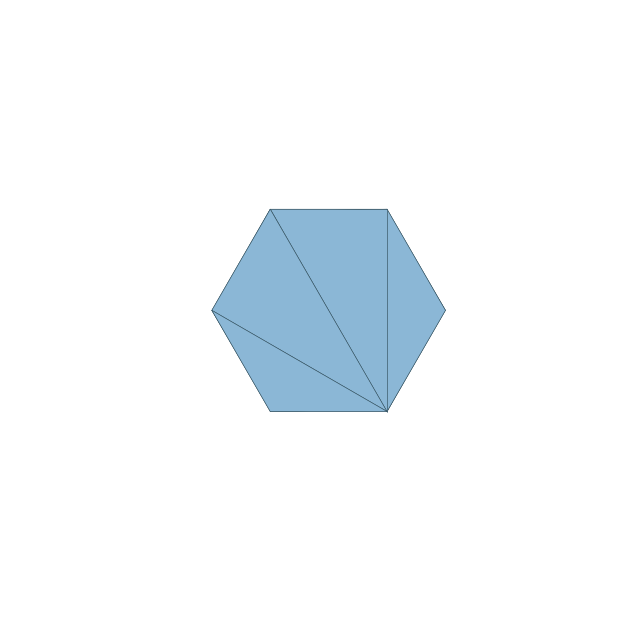
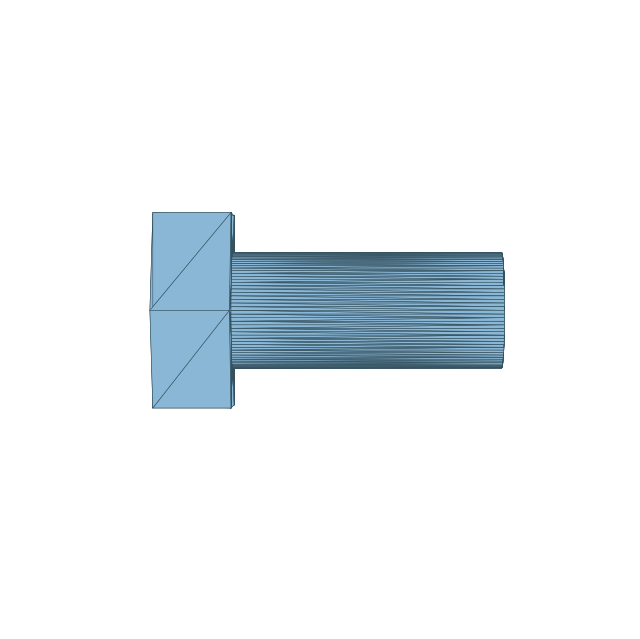
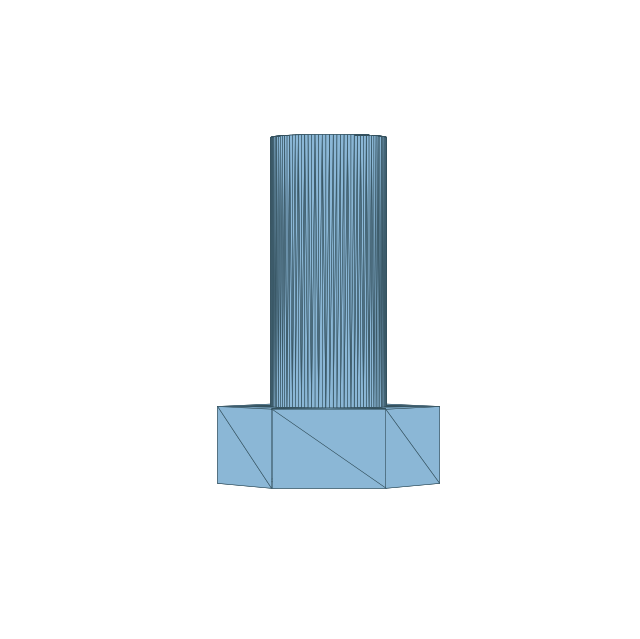
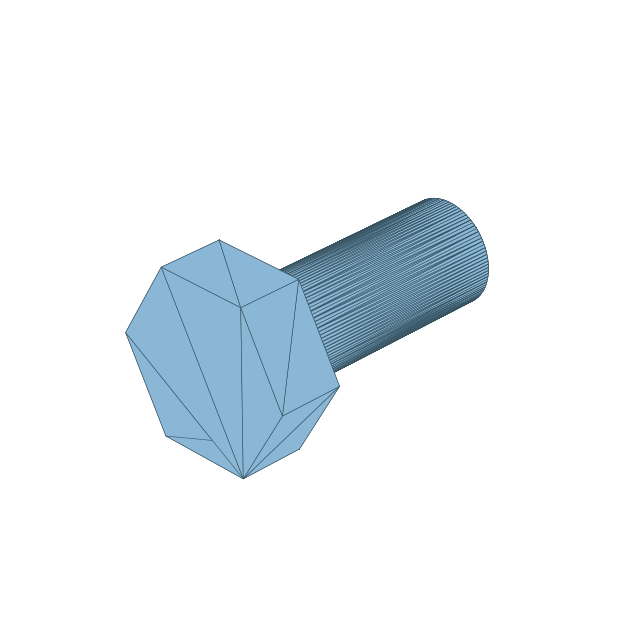
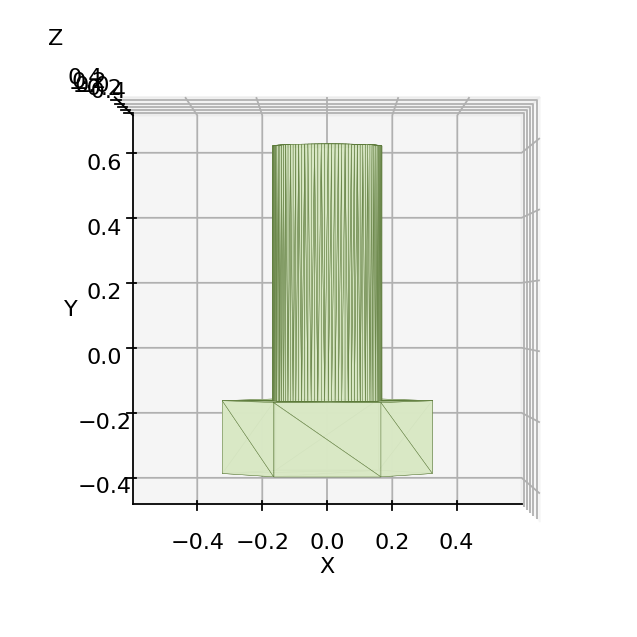

  → code hash : f461d1e3f361f9e7d0099d658406e7f822ad1f2a49136121b0177bb10810bdf8
  → step path : /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/original.step
  → stl path  : /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/original.stl


In [6]:
print("[STAGE] Load State A artifacts")
sample = api.load_sample(connection_string, sample_id=sample_id)
original_prompt_path = state_a_dir / "original_prompt.txt"
original_code_path = state_a_dir / "database_original_code.py"
state_a_step_path = state_a_dir / "original.step"
state_a_stl_path = state_a_dir / "original.stl"
state_a_views_dir = state_a_dir / "views"
assert original_prompt_path.exists()
assert original_code_path.exists()
assert state_a_step_path.exists()
assert state_a_stl_path.exists()

original_prompt = original_prompt_path.read_text(encoding="utf-8")
original_code = original_code_path.read_text(encoding="utf-8")
display(Markdown("## State A original prompt"))
display(Markdown(f"```text\n{original_prompt}\n```"))
display_image_row("State A views", [(name, state_a_views_dir / f"{name}.png") for name in ["front", "side", "top", "iso", "grid"]])
print(f"  → code hash : {__import__('hashlib').sha256(original_code.encode('utf-8')).hexdigest()}")
print(f"  → step path : {state_a_step_path}")
print(f"  → stl path  : {state_a_stl_path}")


In [7]:
print("[STAGE] Build FEA load case and prompt")
load_case_path = state_b_dir / "load_case.json"
selector_hints_path = state_b_dir / "selector_hints.json"
revision_prompt_path = state_b_dir / "fea_revision_prompt.txt"
load_case = api.write_load_case(sample_id, load_case_path, force=True)
selector_hints = api.write_selector_hints(load_case, selector_hints_path, force=True)
revision_prompt = api.build_fea_prompt(original_prompt, original_code, load_case, selector_hints)
revision_prompt_path.write_text(revision_prompt, encoding="utf-8")

print(f"  → load case     : {load_case_path}")
print(f"  → selector hints: {selector_hints_path}")
print(f"  → prompt file   : {revision_prompt_path}")
print(f"  → prompt lines  : {len(revision_prompt.splitlines())}")
print(f"  → material      : {load_case.material}")
print(f"  → fixed region  : {selector_hints.fixed_region_description}")
print(f"  → load region   : {selector_hints.load_region_description}")
display(Markdown("## Revised FEA prompt"))
display(Markdown(f"```text\n{revision_prompt}\n```"))
assert "State A original prompt:" in revision_prompt
assert "State A original DB code:" in revision_prompt
assert "Load case (JSON):" in revision_prompt
assert "Selector hints (JSON):" in revision_prompt
assert "Preserve the original design identity." in revision_prompt
assert "Return only JSON containing code_lines and change_log." in revision_prompt


src.fea.write_load_case | INFO | write_load_case | start | sample_id=00689964 | output_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/02_fea_constrained_revision/load_case.json | force=True
src.fea.write_load_case | INFO | write_load_case | done | sample_id=00689964 | output_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/02_fea_constrained_revision/load_case.json | max_von_mises_pa=138000000
src.fea.write_load_case | INFO | write_selector_hints | start | sample_id=00689964 | output_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/02_fea_constrained_revision/selector_hints.json | force=True
src.fea.write_load_case | INFO | write_selector_hints | done | sample_id=00689964 | output_path=/Us

[STAGE] Build FEA load case and prompt
  → load case     : /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/02_fea_constrained_revision/load_case.json
  → selector hints: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/02_fea_constrained_revision/selector_hints.json
  → prompt file   : /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/02_fea_constrained_revision/fea_revision_prompt.txt
  → prompt lines  : 114
  → material      : {'name': 'Aluminum 6061-T6', 'youngs_modulus_pa': 68900000000, 'poissons_ratio': 0.33, 'yield_strength_pa': 276000000}
  → fixed region  : wall-facing mounting plate face
  → load region   : top face near free end


## Revised FEA prompt

```text
Revise the original DB CadQuery design with FEA constraints.

State A original prompt:
Write Python code using CadQuery imported as cq.
declare diameter = 0.321427, cylinder_length = 0.75025, sides = 6, length = 0.61859, extrude = 0.214286
create cyl workplane "XZ" cylinder_length, diameter/2
cyl faces "-Y" polygon sides, length workplane().extrude
translate y axis cylinder_length/2

State A original DB code:
```python
import cadquery as cq

diameter:float = 0.321427
cylinder_length:float = 0.75025

sides:int = 6
length:float = 0.61859
extrude:float = 0.214286

cylinder = cq.Workplane("XZ").cylinder(cylinder_length, diameter/2)
part:cq.Workplane = cylinder.faces("-Y").polygon(sides, length).workplane().extrude(extrude)

part = part.translate((0,cylinder_length/2,0))

cq.exporters.export(part, 'Ground_Truth.stl')
```

Load case (JSON):
{
  "boundary_conditions": [
    {
      "description": "User-defined or model-inferred fixed support region",
      "id": "fixed_region",
      "selector": null,
      "type": "fixed_displacement"
    }
  ],
  "loads": [
    {
      "description": "User-defined or model-inferred load application region",
      "direction": [
        0,
        0,
        -1
      ],
      "id": "load_region",
      "magnitude_n": 200,
      "selector": null,
      "type": "force"
    }
  ],
  "material": {
    "name": "Aluminum 6061-T6",
    "poissons_ratio": 0.33,
    "yield_strength_pa": 276000000,
    "youngs_modulus_pa": 68900000000
  },
  "requirements": {
    "max_displacement_mm": 1.0,
    "max_von_mises_pa": 138000000,
    "required_safety_factor": 2.0
  },
  "sample_id": "00689964",
  "units": "mm"
}

Selector hints (JSON):
{
  "fixed_region_description": "wall-facing mounting plate face",
  "fixed_region_selector": {
    "axis": "x",
    "side": "minimum"
  },
  "load_region_description": "top face near free end",
  "load_region_selector": {
    "axis": "x",
    "side": "maximum"
  },
  "notes": [
    "Confirm the fixed region before running FreeCAD FEM.",
    "Confirm the load region before running FreeCAD FEM."
  ],
  "sample_id": "00689964"
}

Required content checklist:
- original prompt
- original DB code
- load case
- selector hints
- preserve identity
- permitted modifications
- machine-readable change log

State B revision instructions:
- Preserve the original design identity.
- Revise State A instead of designing an unrelated part.
- Keep the same functional intent, silhouette, and mounting logic where possible.
- Use only permitted modifications such as thickness changes, ribs, gussets, fillets, local strengthening, and support/load face cleanup.
- Keep the geometry as one connected solid when possible.
- Keep the result meshable and manufacturable.
- Do not introduce decorative or unrelated features.

Machine-readable change-log instructions:
- Return a machine-readable change_log object.
- Each change_log entry must describe the changed feature, change type, reason, and expected physical effect.
- Record whether the original design identity was preserved.
- Return only JSON containing code_lines and change_log.

Additional output requirements:
- Prompt output requirement: include original prompt, original DB code, load case, selector hints, identity-preservation rules, and machine-readable change-log instructions.
- Code output requirement: return runnable CadQuery Python code using import cadquery as cq and a result variable.
- Change-log requirement: describe modifications in a machine-readable structure.
```

In [8]:
print("[STAGE] Generate the FEA revision")
state_b_code_path = state_b_dir / "fea_revision_code.py"
state_b_step_path = state_b_dir / "fea_revision.step"
state_b_stl_path = state_b_dir / "fea_revision.stl"
state_b_views_dir = state_b_dir / "views"
state_b_change_log_path = state_b_dir / "fea_revision_change_log.json"
state_b_provenance_path = state_b_dir / "provenance.json"
state_b_log_path = state_b_dir / "execution_log.txt"
state_b_annotated_path = state_b_views_dir / "annotated_support_load.png"

revision_result = None
required_artifacts = [revision_prompt_path, state_b_code_path, state_b_change_log_path, state_b_provenance_path, state_b_step_path, state_b_stl_path, state_b_log_path, state_b_annotated_path]
if all(path.exists() for path in required_artifacts):
    print("  → existing State B artifacts found; loading them")
else:
    if not os.environ.get("OPENAI_API_KEY"):
        raise RuntimeError(f"OPENAI_API_KEY is required to generate State B artifacts when they do not already exist. Populate {API_ENV_PATH} or export the variable before running this cell.")
    revision_result = api.revise_code_for_fea(original_prompt, original_code, load_case, selector_hints, pipeline_config)
    state_b_code_path = revision_result.code_path
    state_b_step_path = revision_result.step_path
    state_b_stl_path = revision_result.stl_path
    state_b_views_dir = state_b_dir / "views"
    state_b_change_log_path = revision_result.change_log_path
    state_b_provenance_path = revision_result.provenance_path

state_b_code = state_b_code_path.read_text(encoding="utf-8")
if not state_b_step_path.exists() or not state_b_stl_path.exists():
    execution = api.execute_and_export_fea_revision_cadquery(state_b_code, state_b_dir, force=True)
    state_b_step_path = Path(execution["step_path"])
    state_b_stl_path = Path(execution["stl_path"])
if not state_b_annotated_path.exists():
    api.render_support_load_annotation(state_b_stl_path, state_b_annotated_path, selector_hints, force=True)
view_paths = api.render_views(state_b_stl_path, state_b_views_dir, force=True)
comparison_image_path = comparison_dir / "state_a_vs_state_b.png"
api.build_side_by_side_comparison(state_a_views_dir, state_b_views_dir, comparison_image_path, force=True)
comparison_paths = api.build_comparison_artifacts(original_prompt, revision_prompt, comparison_dir, notes={"sample_id": sample_id, "state_a_step": str(state_a_step_path), "state_b_step": str(state_b_step_path)}, force=True)
metrics_json_path = comparison_dir / "geometry_metrics.json"
metrics_md_path = comparison_dir / "geometry_metrics.md"
geometry_metrics = api.compute_geometry_metrics({"State A": state_a_stl_path, "State B": state_b_stl_path}, metrics_json_path, force=True)
api.build_geometry_metrics_markdown(geometry_metrics, metrics_md_path, force=True)

print(f"  → code path    : {state_b_code_path}")
print(f"  → step path    : {state_b_step_path}")
print(f"  → stl path     : {state_b_stl_path}")
print(f"  → annotated    : {state_b_annotated_path}")
print(f"  → comparison   : {comparison_image_path}")
print(f"  → metrics json : {metrics_json_path}")
display(Markdown("## State A vs State B"))
display(Image(filename=str(comparison_image_path)))
display(Markdown("## State B annotated support/load view"))
display(Image(filename=str(state_b_annotated_path)))
display(Markdown("## State B geometry metrics"))
display(Markdown(metrics_md_path.read_text(encoding="utf-8")))


src.cad.generate_fea_ready | INFO | revise_code_for_fea | start | sample_id=00689964 | output_root=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs | prompt_length=298 | code_length=400
src.config | INFO | load_config | start | config_name=config_gpt_5_4_mini.yaml | config_dir=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/src/copied_from_cadcodeverify/configs
src.config | INFO | load_config | done | config_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/src/copied_from_cadcodeverify/configs/config_gpt_5_4_mini.yaml | keys=['analysis', 'computation_graph', 'db', 'evaluation', 'generation', 'model', 'variants', 'version']
src.prompts.build_fea_prompt | INFO | build_fea_prompt | start | sample_id=00689964 | prompt_length=298 | code_length=400 | load_case_keys=['b

[STAGE] Generate the FEA revision


httpx | INFO | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 404 Not Found"
src.cad.generate_fea_ready | ERROR | revise_code_for_fea | failed | sample_id=00689964 | output_root=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs
Traceback (most recent call last):
  File "/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/src/copied_from_cadcodeverify/llm/llm.py", line 295, in generate_with_metadata
    response = _call(create_kwargs)
  File "/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/src/copied_from_cadcodeverify/llm/llm.py", line 254, in _call
    response = self.client.chat.completions.create(**call_kwargs)
  File "/opt/homebrew/Caskroom/miniconda/base/envs/cad_physics/lib/python3.10/site-packages/openai/_utils/_utils.py", line 286, in wrap

ConnectorError: Openai generation failed: Error code: 404 - {'error': {'message': 'The model `unknown` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'param': None, 'code': 'model_not_found'}}

In [ ]:
print("[STAGE] Assertions")
assert state_b_code_path.exists()
assert state_b_step_path.exists()
assert state_b_stl_path.exists()
assert state_b_annotated_path.exists()
assert comparison_image_path.exists()
assert comparison_paths["prompt_diff"]
assert comparison_paths["geometry_diff_notes"]
assert metrics_json_path.exists()
assert metrics_md_path.exists()
change_log = json.loads(state_b_change_log_path.read_text(encoding="utf-8"))
provenance = json.loads(state_b_provenance_path.read_text(encoding="utf-8"))
print(f"  → change log keys : {sorted(change_log.keys())}")
print(f"  → provenance keys : {sorted(provenance.keys())}")
assert change_log["sample_id"] == sample_id
assert provenance["sample_id"] == sample_id
assert change_log["changed_features"]
assert provenance["prompt_source"]
print("  ✓ State B revision is traceable")


## What this notebook proves

- FEA constraints produced a traceable revision of the original DB design.
- Before/after views and comparison artifacts are saved.
- Geometry deltas are measurable.
